# 探索的データ分析（EDA）

本ノートブックはデータの基本的な把握と仮説形成を目的とした探索的分析である。  
図1（収入分布）の作成と、各変数の分布・収入との関係の確認を主な目的とする。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

sns.set()

In [2]:
df = pd.read_csv('../data/adult.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [3]:
# 2値分類の目的変数の作成
df["income_binary"] = (df["income"] == ">50K").astype(int)

In [4]:
# ageのビン分割
df['age_bin'] = pd.cut(
    df['age'],
    bins=[0,20,30,40,50,60,100],
    labels=['~19','20~29','30~39','40~49','50~59','60~'], 
    right=False
)

In [5]:
# 新しい特徴量の作成
df['capital_gain_flag'] = (df['capital.gain'] > 0).astype(int)
df['capital_loss_flag'] = (df['capital.loss'] > 0).astype(int)

In [6]:
# 列名のドットをアンダーバーに置換
df.columns = df.columns.str.replace('.', '_', regex=False)

In [7]:
# 不要列削除
df = df.drop(columns=['fnlwgt', 'education', 'capital_gain', 'capital_loss', 'income'])

In [8]:
# 列の並び替え
df = df[['age', 'workclass', 'education_num', 'marital_status', 'occupation', 
         'relationship', 'race','sex','hours_per_week', 'native_country', 
         'capital_gain_flag', 'capital_loss_flag', 'age_bin', 'income_binary']]

In [9]:
# train_test分割
train_df, test_df = train_test_split(df, test_size=0.2, random_state=123)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26048 entries, 0 to 26047
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                26048 non-null  int64   
 1   workclass          26048 non-null  str     
 2   education_num      26048 non-null  int64   
 3   marital_status     26048 non-null  str     
 4   occupation         26048 non-null  str     
 5   relationship       26048 non-null  str     
 6   race               26048 non-null  str     
 7   sex                26048 non-null  str     
 8   hours_per_week     26048 non-null  int64   
 9   native_country     26048 non-null  str     
 10  capital_gain_flag  26048 non-null  int64   
 11  capital_loss_flag  26048 non-null  int64   
 12  age_bin            26048 non-null  category
 13  income_binary      26048 non-null  int64   
dtypes: category(1), int64(6), str(7)
memory usage: 4.3 MB


In [11]:
train_df.isnull().sum()

age                  0
workclass            0
education_num        0
marital_status       0
occupation           0
relationship         0
race                 0
sex                  0
hours_per_week       0
native_country       0
capital_gain_flag    0
capital_loss_flag    0
age_bin              0
income_binary        0
dtype: int64

In [12]:
train_df.describe()

,age,education_num,hours_per_week,capital_gain_flag,capital_loss_flag,income_binary
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.586686,10.070485,40.433239,0.084152,0.046760,0.239481
std,13.619181,2.572231,12.346313,0.277621,0.211128,0.426775
min,17.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,28.000000,9.000000,40.000000,0.000000,0.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000,0.000000,0.000000
75%,48.000000,12.000000,45.000000,0.000000,0.000000,0.000000
max,90.000000,16.000000,99.000000,1.000000,1.000000,1.000000


In [13]:
train_df.describe(include='object')

/var/folders/67/_4bdb9qn7l96hjbkqm852wxw0000gn/T/ipykernel_1184/1490267509.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include='object')


,workclass,marital_status,occupation,relationship,race,sex,native_country
count,26048,26048,26048,26048,26048,26048,26048
unique,9,7,15,6,5,2,42
top,Private,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,18168,11988,3298,10555,22264,17419,23338


In [14]:
train_df['income_binary'].value_counts()

income_binary
0    19810
1     6238
Name: count, dtype: int64

In [15]:
train_df['income_binary'].value_counts(normalize=True)

income_binary
0    0.760519
1    0.239481
Name: proportion, dtype: float64

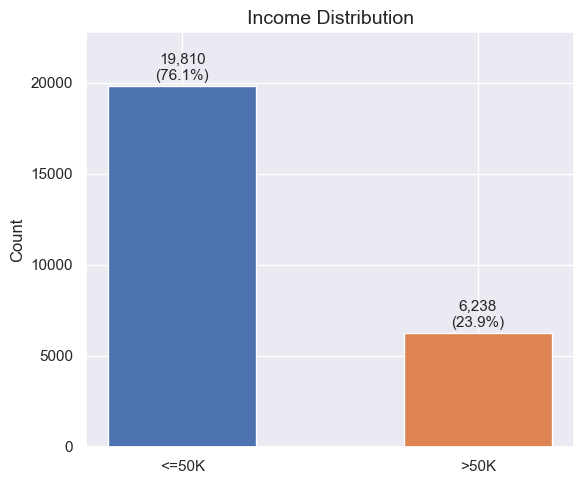

In [16]:
# ============================================================
# 図1： 収入分布
# ============================================================

labels = ['<=50K', '>50K']
counts = train_df['income_binary'].value_counts().reindex([0, 1])

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts, color=['#4C72B0', '#DD8452'], width=0.5)

# 各バーの上に件数とパーセントを表示
total = counts.sum()
for bar, count in zip(bars, counts):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )

plt.title('Income Distribution', fontsize=14)
plt.ylabel('Count')
plt.ylim(0, counts.max() * 1.15)  # ラベルが収まるよう上部に余白
plt.tight_layout()
plt.savefig('../images/income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education_num'}>],
       [<Axes: title={'center': 'hours_per_week'}>,
        <Axes: title={'center': 'capital_gain_flag'}>],
       [<Axes: title={'center': 'capital_loss_flag'}>,
        <Axes: title={'center': 'income_binary'}>]], dtype=object)

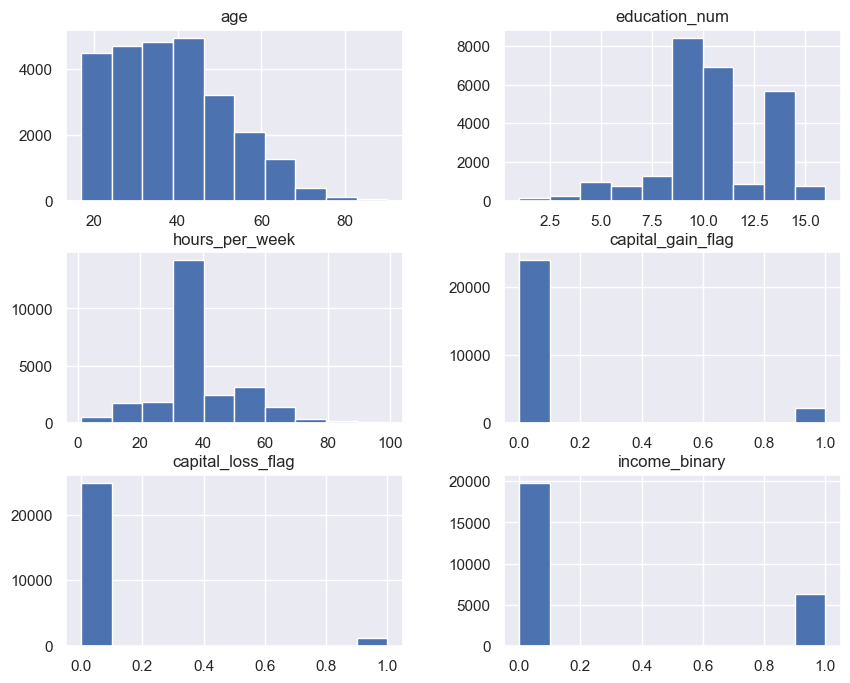

In [17]:
train_df.hist(figsize=(10,8))

In [18]:
train_df[['age', 'education_num', 'hours_per_week', 'capital_gain_flag', 'capital_loss_flag', 'income_binary']].corr()

,age,education_num,hours_per_week,capital_gain_flag,capital_loss_flag,income_binary
age,1.000000,0.036231,0.072161,0.122000,0.051184,0.232891
education_num,0.036231,1.000000,0.144494,0.113304,0.075442,0.330856
hours_per_week,0.072161,0.144494,1.000000,0.077861,0.053513,0.227867
capital_gain_flag,0.122000,0.113304,0.077861,1.000000,-0.067136,0.266699
capital_loss_flag,0.051184,0.075442,0.053513,-0.067136,1.000000,0.140315
income_binary,0.232891,0.330856,0.227867,0.266699,0.140315,1.000000


In [19]:
train_df['education_num'].value_counts()

education_num
9     8402
10    5812
13    4308
14    1365
11    1106
7      944
12     852
6      759
4      524
15     458
5      428
8      341
16     311
3      267
2      130
1       41
Name: count, dtype: int64

| education    | education-num |
| ------------ | ------------- |
| Preschool    | 1             |
| 1st-4th      | 2             |
| 5th-6th      | 3             |
| 7th-8th      | 4             |
| 9th          | 5             |
| 10th         | 6             |
| 11th         | 7             |
| 12th         | 8             |
| HS-grad      | 9             |
| Some-college | 10            |
| Assoc-voc    | 11            |
| Assoc-acdm   | 12            |
| Bachelors    | 13            |
| Masters      | 14            |
| Prof-school  | 15            |
| Doctorate    | 16            |

In [20]:
train_df.loc[train_df['occupation'] == 'Protective-serv']['workclass'].value_counts()

workclass
Local-gov           236
Private             152
State-gov            85
Federal-gov          20
Self-emp-not-inc      6
Self-emp-inc          4
Name: count, dtype: int64

In [21]:
train_df['workclass'].value_counts()

workclass
Private             18168
Self-emp-not-inc     2044
Local-gov            1689
?                    1448
State-gov            1045
Self-emp-inc          878
Federal-gov           760
Without-pay            11
Never-worked            5
Name: count, dtype: int64

| 値                    | 意味            | 補足                |
| -------------------- | ------------- | ----------------- |
| **Private**          | 民間企業          | 一番多い。一般企業の会社員     |
| **Self-emp-not-inc** | 自営業（法人化していない） | 個人事業主             |
| **Self-emp-inc**     | 自営業（法人化している）  | 小規模会社の経営者         |
| **Federal-gov**      | 連邦政府職員        | 国家公務員             |
| **State-gov**        | 州政府職員         | 州公務員              |
| **Local-gov**        | 地方自治体職員       | 市・郡などの公務員         |
| **Without-pay**      | 無給労働          | 家業の手伝いなど          |
| **Never-worked**     | 就労経験なし        | 失業というより「働いたことがない」 |
| **?**                | 欠損値           | 回答なし              |

In [22]:
train_df['marital_status'].value_counts()

marital_status
Married-civ-spouse       11988
Never-married             8524
Divorced                  3544
Separated                  827
Widowed                    810
Married-spouse-absent      338
Married-AF-spouse           17
Name: count, dtype: int64

| 値                     | 意味              | 日本語の近い概念 |
| --------------------- | --------------- | -------- |
| Married-civ-spouse    | 配偶者と同居している既婚    | 既婚       |
| Never-married         | 一度も結婚したことがない    | 未婚       |
| Divorced              | 離婚              | 離婚       |
| Separated             | 別居中             | 別居       |
| Widowed               | 配偶者が死亡          | 死別       |
| Married-spouse-absent | 既婚だが配偶者が同居していない | 単身赴任など   |
| Married-AF-spouse     | 配偶者が軍人          | 軍人配偶者    |

In [23]:
train_df['occupation'].value_counts()

occupation
Prof-specialty       3298
Craft-repair         3259
Exec-managerial      3258
Adm-clerical         3025
Sales                2937
Other-service        2628
Machine-op-inspct    1615
?                    1453
Transport-moving     1288
Handlers-cleaners    1106
Farming-fishing       805
Tech-support          745
Protective-serv       503
Priv-house-serv       120
Armed-Forces            8
Name: count, dtype: int64

| 値                 | 意味       | 日本語イメージ        |
| ----------------- | -------- | -------------- |
| Prof-specialty    | 専門職      | 医師・研究者・エンジニアなど |
| Exec-managerial   | 経営・管理職   | 役員・マネージャー      |
| Adm-clerical      | 事務職      | 事務スタッフ         |
| Sales             | 営業職      | 小売・営業          |
| Tech-support      | ITサポート   | ITサポート・技術支援    |
| Craft-repair      | 熟練技能職    | 大工・電気工など       |
| Machine-op-inspct | 機械オペレーター | 工場作業員          |
| Transport-moving  | 運輸       | トラック運転手など      |
| Handlers-cleaners | 荷役・清掃    | 倉庫作業・清掃        |
| Farming-fishing   | 農林水産業    | 農業・漁業          |
| Protective-serv   | 保安職      | 警察・警備          |
| Other-service     | その他サービス  | 飲食・美容など        |
| Priv-house-serv   | 家事労働     | 家政婦など          |
| Armed-Forces      | 軍        | 軍人             |
| ?                 | 欠損       | 未回答            |

In [24]:
train_df['relationship'].value_counts()

relationship
Husband           10555
Not-in-family      6664
Own-child          4027
Unmarried          2756
Wife               1258
Other-relative      788
Name: count, dtype: int64

`relationship`列は、**その人が「世帯の中でどの立場にいるか**を表す変数

| 値              | 意味         | 日本語イメージ |
| -------------- | ---------- | ------- |
| Husband        | 世帯主の夫      | 夫       |
| Wife           | 世帯主の妻      | 妻       |
| Own-child      | 世帯主の子供     | 子供      |
| Not-in-family  | 世帯主と親族関係なし | 同居人     |
| Unmarried      | 未婚の親族      | 未婚の家族   |
| Other-relative | その他の親族     | 親・兄弟など  |

少し分かりにくいもの
* Not-in-family

これは、世帯主と親族関係がない人。

例
* ルームメイト
* 下宿人
* 同居人
---
* Unmarried

これは、未婚の家族。

例
* 独身の兄弟
* 未婚の親族

In [25]:
train_df['race'].value_counts()

race
White                 22264
Black                  2495
Asian-Pac-Islander      816
Amer-Indian-Eskimo      257
Other                   216
Name: count, dtype: int64

| 値                  | 意味       | 日本語イメージ          |
| ------------------ | -------- | ---------------- |
| White              | 白人       | 欧州系アメリカ人         |
| Black              | 黒人       | アフリカ系アメリカ人       |
| Asian-Pac-Islander | アジア・太平洋系 | 日本、中国、韓国、フィリピンなど |
| Amer-Indian-Eskimo | アメリカ先住民  | ネイティブアメリカンなど     |
| Other              | その他      | 上記に分類されない        |

In [26]:
train_df['sex'].value_counts()

sex
Male      17419
Female     8629
Name: count, dtype: int64

In [27]:
train_df['native_country'].value_counts()

native_country
United-States                 23338
Mexico                          532
?                               475
Philippines                     146
Germany                         108
Canada                           92
Puerto-Rico                      88
El-Salvador                      87
India                            86
Cuba                             74
Jamaica                          69
England                          69
South                            64
Dominican-Republic               56
China                            54
Vietnam                          52
Japan                            52
Poland                           52
Guatemala                        50
Italy                            49
Taiwan                           40
Columbia                         40
Iran                             37
Haiti                            34
Portugal                         31
Nicaragua                        31
Ecuador                          26
Peru         

In [28]:
train_df.groupby('workclass')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
workclass,,
Self-emp-inc,0.547836,878
Federal-gov,0.380263,760
Self-emp-not-inc,0.286693,2044
Local-gov,0.283600,1689
State-gov,0.267943,1045
Private,0.218406,18168
?,0.107044,1448
Never-worked,0.000000,5
Without-pay,0.000000,11


<Axes: xlabel='workclass'>

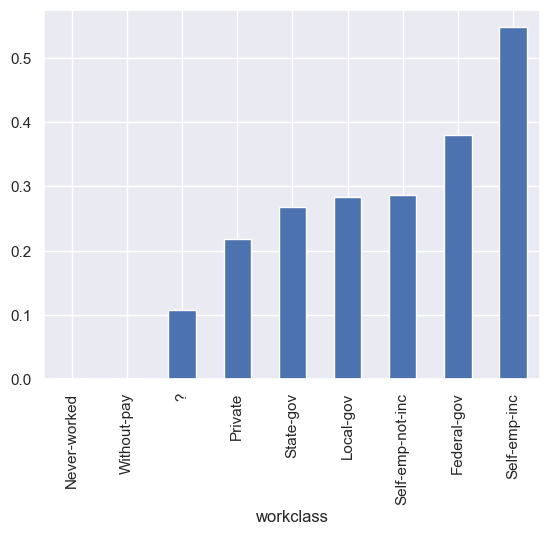

In [29]:
train_df.groupby('workclass')['income_binary'].mean().sort_values().plot(kind='bar')

In [30]:
train_df.groupby('marital_status')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
marital_status,,
Married-civ-spouse,0.445946,11988
Married-AF-spouse,0.352941,17
Divorced,0.102144,3544
Married-spouse-absent,0.079882,338
Widowed,0.079012,810
Separated,0.061669,827
Never-married,0.044815,8524


<Axes: xlabel='marital_status'>

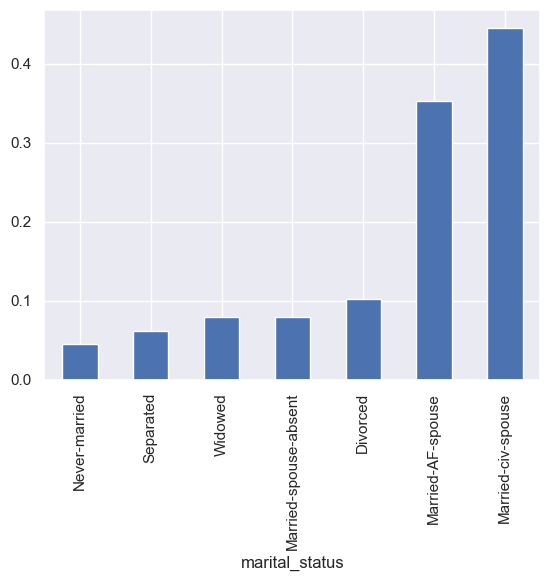

In [31]:
train_df.groupby('marital_status')['income_binary'].mean().sort_values().plot(kind='bar')

In [32]:
train_df.groupby('occupation')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
occupation,,
Exec-managerial,0.484653,3258
Prof-specialty,0.443602,3298
Protective-serv,0.308151,503
Tech-support,0.295302,745
Sales,0.267961,2937
Craft-repair,0.222154,3259
Transport-moving,0.204193,1288
Adm-clerical,0.131570,3025
Machine-op-inspct,0.129412,1615


<Axes: xlabel='occupation'>

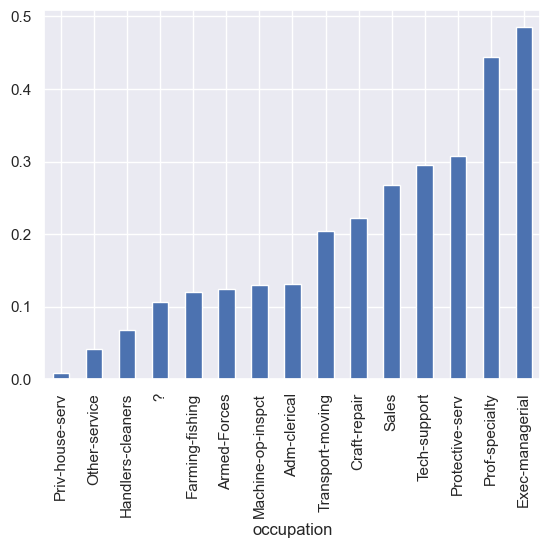

In [33]:
train_df.groupby('occupation')['income_binary'].mean().sort_values().plot(kind='bar')

In [34]:
train_df.groupby('relationship')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
relationship,,
Wife,0.477742,1258
Husband,0.446802,10555
Not-in-family,0.100240,6664
Unmarried,0.060958,2756
Other-relative,0.043147,788
Own-child,0.012665,4027


<Axes: xlabel='relationship'>

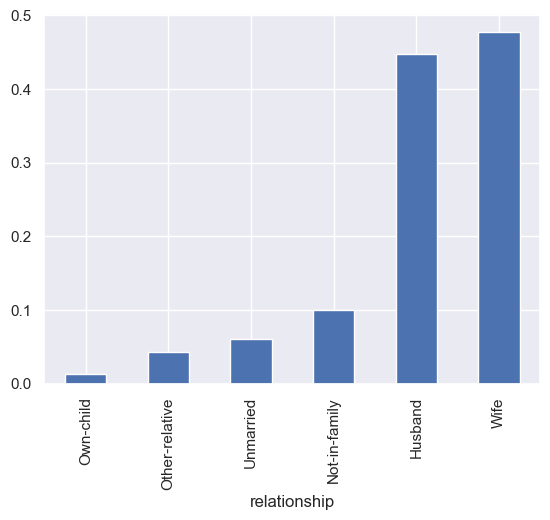

In [35]:
train_df.groupby('relationship')['income_binary'].mean().sort_values().plot(kind='bar')

In [36]:
train_df.groupby('race')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
race,,
Asian-Pac-Islander,0.274510,816
White,0.254267,22264
Black,0.121844,2495
Amer-Indian-Eskimo,0.108949,257
Other,0.097222,216


<Axes: xlabel='race'>

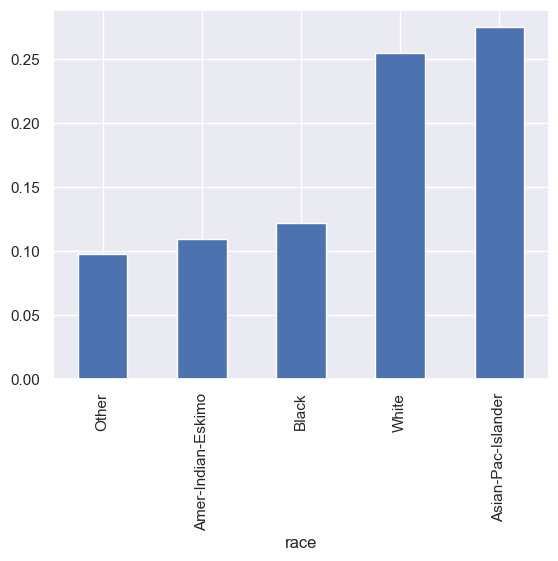

In [37]:
train_df.groupby('race')['income_binary'].mean().sort_values().plot(kind='bar')

In [38]:
train_df.groupby('sex')['income_binary'].agg(['mean','count'])

,mean,count
sex,,
Female,0.110905,8629
Male,0.303175,17419


<Axes: xlabel='sex'>

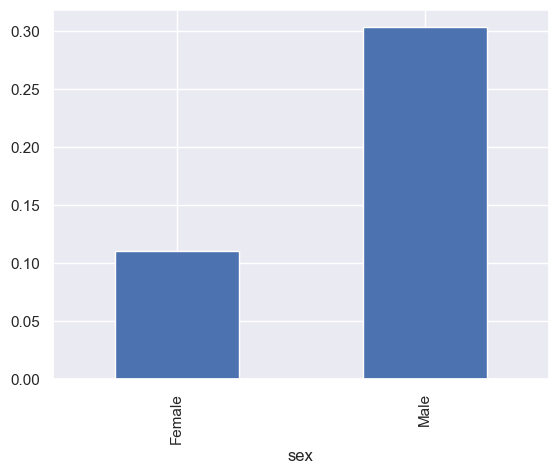

In [39]:
train_df.groupby('sex')['income_binary'].mean().sort_values().plot(kind='bar')

In [40]:
train_df.groupby('native_country')['income_binary'].agg(['mean','count']).sort_values(by='mean', ascending=False)

,mean,count
native_country,,
Cambodia,0.461538,13
France,0.428571,21
India,0.406977,86
Iran,0.405405,37
Japan,0.403846,52
Hong,0.400000,15
Italy,0.387755,49
England,0.376812,69
Taiwan,0.375000,40


<Axes: xlabel='native_country'>

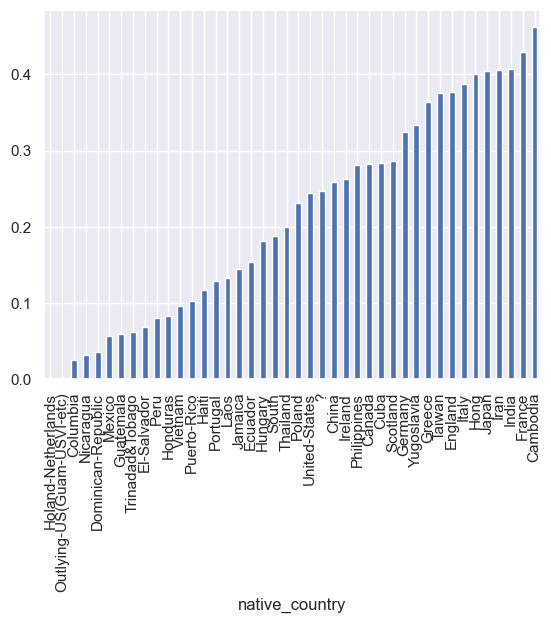

In [41]:
train_df.groupby('native_country')['income_binary'].mean().sort_values().plot(kind='bar')

In [42]:
train_df.groupby('education_num')['income_binary'].agg(['mean','count'])

,mean,count
education_num,,
1,0.000000,41
2,0.038462,130
3,0.059925,267
4,0.066794,524
5,0.056075,428
6,0.068511,759
7,0.051907,944
8,0.073314,341
9,0.159843,8402


<Axes: xlabel='education_num'>

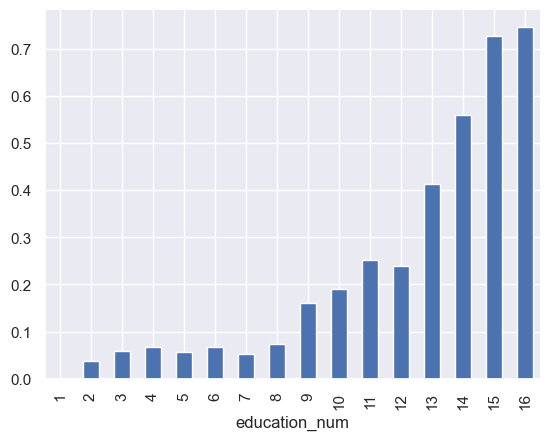

In [43]:
train_df.groupby('education_num')['income_binary'].mean().plot(kind='bar')

In [44]:
train_df.groupby('capital_gain_flag')['income_binary'].agg(['mean','count'])

,mean,count
capital_gain_flag,,
0,0.204980,23856
1,0.614964,2192


<Axes: xlabel='capital_gain_flag'>

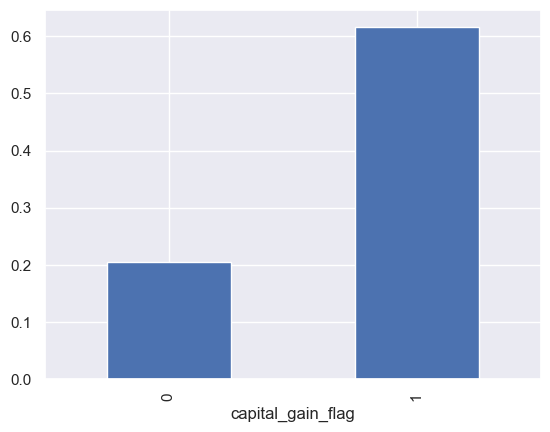

In [45]:
train_df.groupby('capital_gain_flag')['income_binary'].mean().plot(kind='bar')

In [46]:
train_df.groupby('capital_loss_flag')['income_binary'].agg(['mean','count'])

,mean,count
capital_loss_flag,,
0,0.226218,24830
1,0.509852,1218


<Axes: xlabel='capital_loss_flag'>

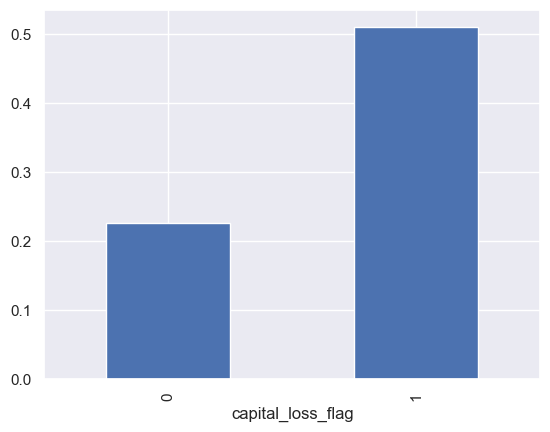

In [47]:
train_df.groupby('capital_loss_flag')['income_binary'].mean().plot(kind='bar')

<Axes: xlabel='income_binary', ylabel='age'>

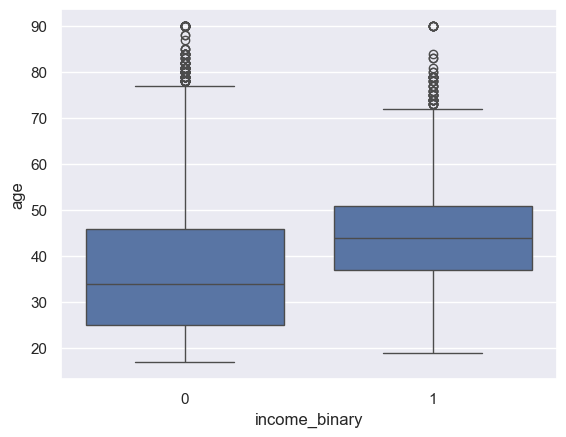

In [48]:
sns.boxplot(x='income_binary', y='age', data=train_df)

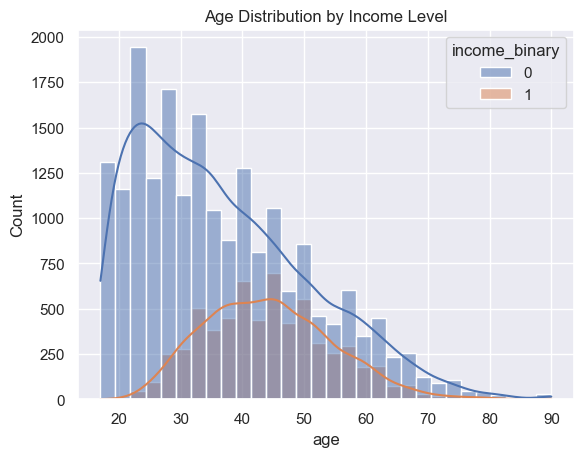

In [49]:
sns.histplot(data=train_df, x='age', hue='income_binary', bins=30, kde=True)

plt.title('Age Distribution by Income Level')
plt.show()

<Axes: xlabel='age'>

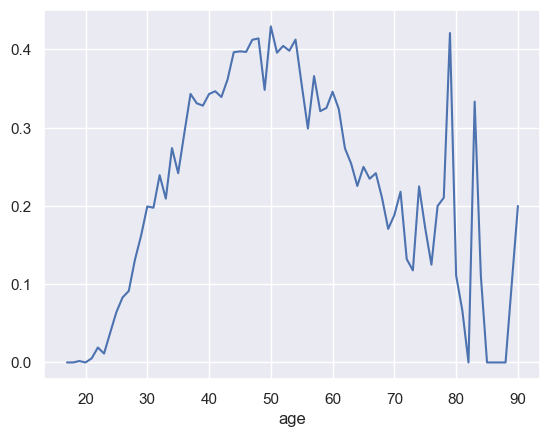

In [50]:
train_df.groupby('age')['income_binary'].mean().plot()

<Axes: xlabel='income_binary', ylabel='hours_per_week'>

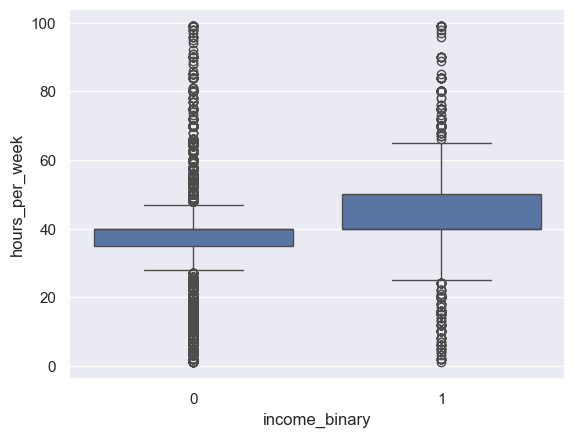

In [51]:
sns.boxplot(x='income_binary', y='hours_per_week', data=train_df)

In [52]:
pd.crosstab(train_df['education_num'], train_df['occupation'])

occupation,?,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
education_num,,,,,,,,,,,,,,,
1,3,2,0,1,0,9,2,9,14,1,0,0,0,0,0
2,8,0,0,17,2,17,15,19,30,8,3,0,4,0,7
3,23,2,0,28,1,30,34,47,51,13,1,1,11,1,24
4,58,9,0,94,16,62,33,75,78,7,8,7,24,5,48
5,41,11,0,86,11,22,45,61,83,8,1,3,24,2,30
6,81,30,0,135,21,33,60,89,158,4,8,5,66,3,66
7,93,58,0,143,28,33,97,77,181,11,18,3,122,6,74
8,32,23,1,47,9,13,31,30,67,4,7,5,38,1,33
9,416,1100,4,1524,664,327,486,810,1042,41,179,169,854,128,658


In [53]:
pd.crosstab(train_df['age_bin'], train_df['education_num'])

education_num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
age_bin,,,,,,,,,,,,,,,,
~19,1,3,7,14,35,149,306,99,339,356,2,1,0,1,0,0
20~29,10,23,62,74,87,155,179,74,2062,1934,270,227,1105,128,36,10
30~39,10,26,51,75,106,138,178,74,2315,1377,369,288,1339,342,121,73
40~49,7,21,54,97,69,97,111,40,1747,1166,276,219,1081,493,171,96
50~59,8,33,51,112,73,131,94,37,1240,641,114,95,518,291,74,83
60~,5,24,42,152,58,89,76,17,699,338,75,22,265,110,56,49


In [54]:
pd.crosstab(train_df['education_num'], train_df['marital_status'], normalize='index')

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
education_num,,,,,,,
1,0.024390,0.000000,0.390244,0.073171,0.487805,0.024390,0.000000
2,0.046154,0.000000,0.446154,0.084615,0.261538,0.046154,0.115385
3,0.052434,0.000000,0.550562,0.063670,0.247191,0.056180,0.029963
4,0.108779,0.000000,0.555344,0.020992,0.181298,0.038168,0.095420
5,0.121495,0.000000,0.448598,0.016355,0.303738,0.058411,0.051402
6,0.122530,0.000000,0.383399,0.017128,0.382082,0.055336,0.039526
7,0.110169,0.000000,0.312500,0.014831,0.489407,0.038136,0.034958
8,0.093842,0.000000,0.310850,0.014663,0.519062,0.032258,0.029326
9,0.151274,0.001071,0.462866,0.011902,0.293978,0.038205,0.040705


In [55]:
pd.crosstab(
    train_df['education_num'],
    train_df['marital_status'],
    values=train_df['income_binary'],
    aggfunc='mean'
)

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
education_num,,,,,,,
1,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN
2,0.000000,NaN,0.086207,0.000000,0.000000,0.000000,0.000000
3,0.000000,NaN,0.102041,0.000000,0.015152,0.000000,0.000000
4,0.000000,NaN,0.106529,0.090909,0.021053,0.000000,0.020000
5,0.038462,NaN,0.093750,0.000000,0.015385,0.000000,0.090909
6,0.021505,NaN,0.161512,0.000000,0.006897,0.023810,0.000000
7,0.057692,NaN,0.122034,0.000000,0.010823,0.000000,0.060606
8,0.031250,NaN,0.216981,0.000000,0.000000,0.000000,0.100000
9,0.048780,0.111111,0.314220,0.030000,0.013360,0.012461,0.052632


In [56]:
pd.crosstab(
    train_df["age_bin"],
    train_df["marital_status"],
    normalize="index"
)

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
age_bin,,,,,,,
~19,0.004570,0.000762,0.015232,0.000762,0.974105,0.003808,0.000762
20~29,0.047079,0.000932,0.224984,0.010099,0.691889,0.023773,0.001243
30~39,0.158820,0.000872,0.522232,0.013514,0.257193,0.039959,0.007411
40~49,0.213925,0.000522,0.589208,0.017929,0.114708,0.043168,0.020540
50~59,0.188595,0.000000,0.632823,0.015299,0.069263,0.031154,0.062865
60~,0.113144,0.000481,0.609533,0.010111,0.054887,0.016370,0.195474


In [57]:
train_df.groupby(["age_bin","marital_status"])["income_binary"].mean()

age_bin  marital_status       
~19      Divorced                 0.000000
         Married-AF-spouse        0.000000
         Married-civ-spouse       0.050000
         Married-spouse-absent    0.000000
         Never-married            0.000000
         Separated                0.000000
         Widowed                  0.000000
20~29    Divorced                 0.026403
         Married-AF-spouse        0.500000
         Married-civ-spouse       0.205801
         Married-spouse-absent    0.030769
         Never-married            0.017965
         Separated                0.032680
         Widowed                  0.125000
30~39    Divorced                 0.070448
         Married-AF-spouse        0.166667
         Married-civ-spouse       0.434891
         Married-spouse-absent    0.021505
         Never-married            0.090395
         Separated                0.054545
         Widowed                  0.078431
40~49    Divorced                 0.117168
         Married-AF-spo

In [58]:
train_df.groupby(["education_num","marital_status"])["income_binary"].mean()

education_num  marital_status       
1              Divorced                 0.000000
               Married-civ-spouse       0.000000
               Married-spouse-absent    0.000000
               Never-married            0.000000
               Separated                0.000000
                                          ...   
16             Married-civ-spouse       0.846154
               Married-spouse-absent    0.400000
               Never-married            0.542373
               Separated                0.400000
               Widowed                  0.333333
Name: income_binary, Length: 99, dtype: float64

In [59]:
model = smf.logit(
    "income_binary ~ C(marital_status) + age + education_num + hours_per_week",
    data=train_df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.370157
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          income_binary   No. Observations:                26048
Model:                          Logit   Df Residuals:                    26038
Method:                           MLE   Df Model:                            9
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.3276
Time:                        13:24:10   Log-Likelihood:                -9641.9
converged:                       True   LL-Null:                       -14339.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                   